1. Load DataSet
2. Understanding data is the most important thing
   - shape of data
   - column info
   - summary statistics
   - check column names
3. Handling missing values
   - Options:
      - remove rows with missing values
      - fill missing values
      NB: Rule of thumb:
           - Numerical → mean / median
           - Categorical → mode / “Unknown”
4. Remove duplicates
5. Fix data types
6. Rename columns (Clean and consitent)
7. Handle Inconsistent values
8. Detect & handle outliers (Remove outliers -> IQR method-> Q1-1.5*IQR)
9. Remove Irrelevent Columns
10. Final Check


In [7]:
import pandas as pd

In [19]:
# loading the dataset
from os import rename


data = pd.read_csv("data.csv")

# handling duplicates
data = data.drop_duplicates()

# handling missing values
median_age = data["Age"].median()
data["Age"] = data["Age"].fillna(median_age)

# data types formatting
data["Join_Date"] = pd.to_datetime(data["Join_Date"], format="mixed", errors="coerce")

# Logic Checks (Outliers)
# The Problem: Look at Dave (Index 4). He is 200 years old. While this isn't "missing" and it isn't a "format" error, it is logically impossible. This is likely a typo (maybe he meant 20).
# The Logic: We usually set "boundaries." If Age > 100, we flag it.
data.loc[data["Age"] > 100, "Age"] = 100  # Cap ages at 100

print("Data cleaning complete.")
print(data.head())

# rename columns
data = data.rename(
    columns={
        "Name": "full_name",
        "Age": "age",
        "Join_Date": "join_date",
        "Email": "email",
    }
)
data = data.reset_index(drop=True)  # reset insdex after dropping duplicates

data.to_csv("cleaned_data.csv", index=False)
print("Cleaned data saved to 'cleaned_data.csv'.")

Data cleaning complete.
      Name    Age            Email  Join_Date
0    Alice   25.0  alice@email.com 2023-01-01
1      Bob   30.0    bob@email.com 2023-01-02
2  Charlie   30.0    charlie@email 2023-01-03
4     Dave  100.0   dave@email.com 2023-01-04
Cleaned data saved to 'cleaned_data.csv'.


FROM -> https://lib.stat.cmu.edu/datasets/boston ->**Data Set**


There is 14 columns

from all of the columns:
  - CRIM: Crime rate.
  - RM: Average number of rooms (Important!).
  - LSTAT: % of lower status of the population (Important!).
  - MEDV: Median Value of the house (This is our Target / Price).

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


--- MODEL PERFORMANCE ---
Root Mean Squared Error (RMSE): $4928.60
R^2 Score: $0.67


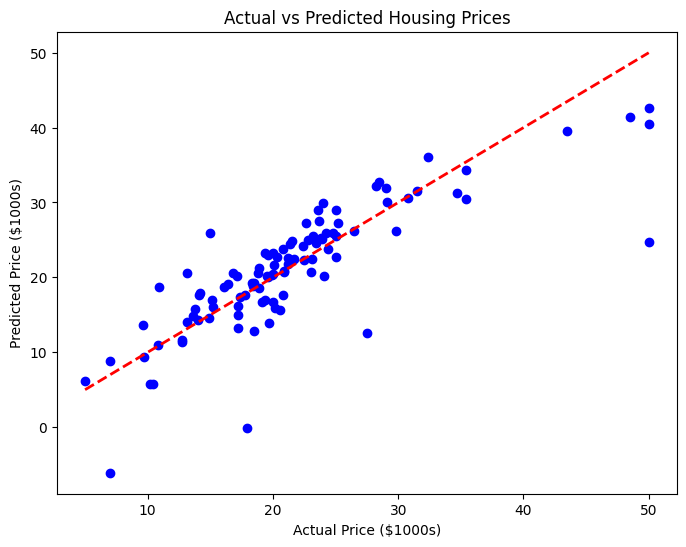


--- FEATURE IMPORTANCE ---
            Weight
RM        4.438835
CHAS      2.784438
RAD       0.262430
INDUS     0.040381
ZN        0.030110
B         0.012351
AGE      -0.006296
TAX      -0.010647
CRIM     -0.113056
LSTAT    -0.508571
PTRATIO  -0.915456
DIS      -1.447865
NOX     -17.202633


In [22]:
# ==========================================
# 1. LOAD AND CLEAN THE DATA
# ==========================================
data_url = "https://lib.stat.cmu.edu/datasets/boston"

# skipping the first 22 rows of metadata -> data is seprated by whitespace -> no header row
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# The dataset has 14 columns, but they are split across two rows. We need to reshape it.
# Line A has 11 columns, Line B has 3 columns. We will combine them.
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :3]])

# Naming the columns
columns = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV",
]
boston_df = pd.DataFrame(data, columns=columns)

# ==========================================
# 2. PREPARE THE DATA
# ==========================================
# X = All columns EXCEPT the price (MEDV)
X = boston_df.drop("MEDV", axis=1)  # X= feature columns
y = boston_df["MEDV"]  # y= the price column

# Split into Train for 80% and Test Sets for 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 3. Train the Model
# ==========================================
model = LinearRegression()
model.fit(X_train, y_train)

# ==========================================
# 4. Evaluate the Model
# ==========================================
y_pred = model.predict(X_test)

# Calculate evaluation metrics -> this means comparing y_test (actual prices) to y_pred (predicted prices) and see how well the model did.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE -> Lower is better
r2 = r2_score(y_test, y_pred)  # R^2 Score -> Higher is better

print("\n--- MODEL PERFORMANCE ---")
print(
    f"Root Mean Squared Error (RMSE): ${rmse*1000:.2f}"
)  # we multiply by 1000 to convert to dollars because MEDV is in $1000s
print(
    f"R^2 Score: ${r2:.2f}"
)  # 1.0 is perfect, 0.0 is useless. Usually 0.6-0.8 is considered 'okay' for this dataset.


# ==========================================
# 5. VISUALIZE (Actual vs Predicted)
# ==========================================
plt.figure(
    figsize=(8, 6)
)  # What do we do with figure? ans: we set the size of the plot
plt.scatter(
    y_test, y_pred, c="blue"
)  # Scatter plot of actual vs predicted prices -> with scatter we can see the correlation
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()], "r--", lw=2
)  # Diagonal line for reference -> this line represents perfect predictions , 'r--'-> red dashed line
plt.xlabel("Actual Price ($1000s)")
plt.ylabel("Predicted Price ($1000s)")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

# ==========================================
# 6. INVESTIGATE: What drives the price? -> means which features are most important?
# ==========================================
coefficient = pd.DataFrame(model.coef_, X.columns, columns=["Weight"])
print("\n--- FEATURE IMPORTANCE ---")
print(coefficient.sort_values(by="Weight", ascending=False))

Let's decode exactly what your specific numbers mean before we improve them.
 1. Decoding Your Results
    - RM (Rooms) = +4.44:
         - The Logic: This is your strongest positive factor (besides the dummy variable CHAS).
         - Translation: For every 1 additional room a house has, its value increases by roughly $4,440 (keeping all else equal).
    - NOX (Nitric Oxide/Pollution) = -17.20:
         - The Logic: This is a massive negative weight.
         - Translation: Pollution kills property value. If the NOX concentration goes up by 1 unit, the property value crashes by $17,200.
    - LSTAT (Lower Status Population) = -0.51:
         - The Logic: This is negative, meaning higher poverty rates in the area correlate with lower house prices.
         - The Hidden Issue: -0.51 seems small, but LSTAT ranges from 1% to 37%. A change of 10% in LSTAT would drop the price by $5,100 ($0.51 * 10 * 1000).
 2. The Problem: Why only 67% Accuracy?
    R² Score is 0.67. This is decent, but it means 33% of the price variation is still unexplained.

    Why?Linear Regression assumes the relationship is a Straight Line.But look at LSTAT (Poverty) vs Price. In the real world, this relationship is usually curved.
    - A little bit of poverty might drop the price slightly.
    - A lot of poverty might drop the price drasticall, but eventually, it flattens out (the price can't go below zero).A straight line cannot capture this curve. It will "underfit" the data. To fix this, we need to let the line bend.
 3. The Solution: Polynomial Regression
    - We don't need a new algorithm. We just need to "trick" the Linear Regression.Instead of just giving it x (LSTAT), we give it x AND x² (LSTAT squared).
                    y = w_1x + w_2x^2 + b
    - By adding the squared term, the model can now draw a parabola (curve) instead of a straight line.
 4. Step-by-Step Code: Adding "Curves"We will use PolynomialFeatures from Scikit-Learn to automatically create these squared variables (x^2) and interaction terms (x_1 * x_2) for us.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# ----------------------------------Extra thing----------------------------------------
# ==========================================
# 7. BONUS: Try a Polynomial Regression to improve accuracy
# ==========================================
# 1. Create the Polynomial "Engine"
# degree=2 means we create x^2 terms.
# include_bias=False because LinearRegression adds its own bias later.
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transform the Data (Make it curvy!)
# We transform BOTH train and test data so they have the same shape
X_train_poly = poly.fit_transform(
    X_train
)  # -> fit_transform means we fit the transformer to X_train and then transform it
X_test_poly = poly.transform(
    X_test
)  # -> transform X_test using the already fitted transformer

print(f"Original features: {X_train.shape[1]}")  # Should be 13
print(f"Polynomial features: {X_train_poly.shape[1]}")
# Likely 100+ features now (original + squares + interactions)
# ----------------------------------Extra thing----------------------------------------

# 3. Train the same Linear Regression on the NEW data
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# 4. Evaluate
y_pred_poly = model_poly.predict(X_test_poly)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("\n--- POLYNOMIAL MODEL PERFORMANCE ---")
print(f"RMSE (Error): ${rmse_poly*1000:.2f}")
print(f"R-Squared: {r2_poly:.2f}")

print(f"\nImprovement in Accuracy: {(r2_poly - 0.67) * 100:.1f}%")